# AutoEIT — Raw-recording Spanish-narrative window length

For every recording with `data/transcribed/v2` output, `src/preprocessing/build_raw_timestamps.py`
recomputes raw-recording-relative VAD timestamps (Silero VAD + the same 2.5s merge-gap threshold
used originally) and looks up the `[beginning, end]` window (in seconds) spanning the first
through last re-transcribed item -- i.e. from where the English instructions end to where the
last Spanish target sentence ends. Results are saved per version at
`data/raw/audio_files/{version}/segment_window_timestamps.json`.

A handful of recordings (3 of 187) were skipped where the recomputed VAD item count didn't match
the number of clips already on disk in `data/segmented/` -- for those, item indices can't be
trusted to line up, so no window was computed rather than risk a silently wrong one.

This notebook loads those windows and plots the distribution of their length
(`end - beginning`) -- the size of the region we'd want to re-segment with a different pause
threshold.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

## Load window timestamps

In [2]:
VERSIONS = ["version_a", "version_b"]
RAW_ROOT = Path("../../data/raw/audio_files")

rows = []
for version in VERSIONS:
    path = RAW_ROOT / version / "segment_window_timestamps.json"
    data = json.loads(path.read_text(encoding="utf-8"))
    for recording, entry in data.items():
        rows.append({
            "version": version,
            "recording": recording,
            "beginning": entry["beginning"],
            "end": entry["end"],
            "length": round(entry["end"] - entry["beginning"], 3),
            "min_item_index": entry["min_item_index"],
            "max_item_index": entry["max_item_index"],
        })

windows = pd.DataFrame(rows)
print(f"{len(windows)} recordings with a computed window")
windows.head()

184 recordings with a computed window


,version,recording,beginning,end,length,min_item_index,max_item_index
0,version_a,038.069_EITv-2A,173.9,544.5,370.6,8,37
1,version_a,038.070_EITv-1A,166.0,536.8,370.8,7,36
2,version_a,038.071_EITv2A,166.9,538.1,371.2,7,36
3,version_a,038.072_EITv1A,164.4,535.6,371.2,7,37
4,version_a,038.073_EITv2A,175.3,549.0,373.7,8,37


## Summary statistics

In [3]:
windows.groupby("version")["length"].describe(percentiles=[.25, .5, .75, .9]).round(2)

,count,mean,std,min,25%,50%,75%,90%,max
version,,,,,,,,,
version_a,94.0,379.05,13.86,354.5,371.6,372.65,375.60,407.15,410.8
version_b,90.0,395.00,16.10,367.1,385.9,387.20,391.58,426.24,429.1


In [4]:
print("Combined (both versions):")
windows["length"].describe(percentiles=[.25, .5, .75, .9]).round(2)

Combined (both versions):


count    184.00
mean     386.85
std       16.96
min      354.50
25%      372.48
50%      385.70
75%      388.58
90%      420.14
max      429.10
Name: length, dtype: float64

## Distribution plot

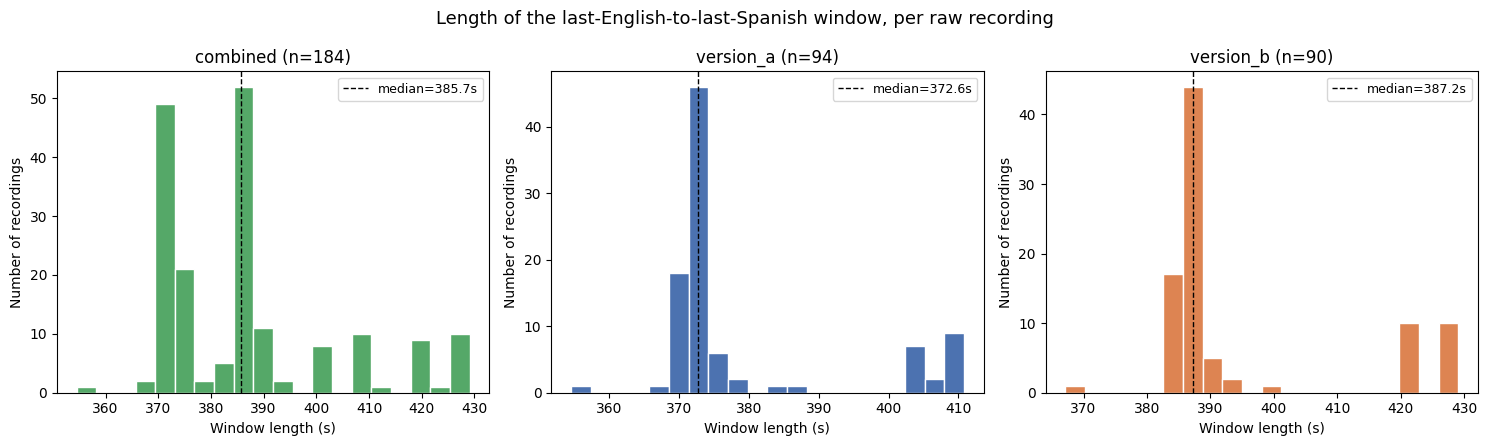

In [5]:
colors = {"version_a": "#4C72B0", "version_b": "#DD8452"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)

panels = [
    ("combined", windows, "#55A868"),
    ("version_a", windows[windows["version"] == "version_a"], colors["version_a"]),
    ("version_b", windows[windows["version"] == "version_b"], colors["version_b"]),
]

for ax, (label, sub, color) in zip(axes, panels):
    ax.hist(sub["length"], bins=20, color=color, edgecolor="white")
    ax.axvline(sub["length"].median(), color="black", linestyle="--", linewidth=1, label=f"median={sub['length'].median():.1f}s")
    ax.set_title(f"{label} (n={len(sub)})", fontsize=12)
    ax.set_xlabel("Window length (s)")
    ax.set_ylabel("Number of recordings")
    ax.legend(fontsize=9)

fig.suptitle("Length of the last-English-to-last-Spanish window, per raw recording", fontsize=13)
fig.tight_layout()
plt.savefig("../plots/raw_window_length_distribution.png", dpi=150)
plt.show()

## Outliers -- shortest and longest windows

In [6]:
print("Shortest:")
display(windows.sort_values("length").head(5)[["recording", "version", "beginning", "end", "length"]])
print("Longest:")
display(windows.sort_values("length", ascending=False).head(5)[["recording", "version", "beginning", "end", "length"]])

Shortest:


,recording,version,beginning,end,length
52,038021_EIT-1A,version_a,166.3,520.8,354.5
46,038014_EIT-2A,version_a,162.0,527.9,365.9
182,038066_EITv-2B,version_b,196.9,564.0,367.1
54,038023_EIT-1A,version_a,170.2,539.8,369.6
8,038.077_EITv-2A,version_a,166.6,537.1,370.5


Longest:


,recording,version,beginning,end,length
117,038.093_EIT1_vB,version_b,129.5,558.6,429.1
106,038.082_EIT2_vB,version_b,126.7,555.7,429.0
109,038.085_EIT1_vB,version_b,127.3,556.3,429.0
110,038.086_EIT2_vB,version_b,129.2,557.3,428.1
111,038.087_EIT1_vB,version_b,127.4,555.5,428.1
